### Question 1: From Prices to Returns

# Question 3

#### 3.1 b)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load annualized expected excess returns and covariance matrix from Q1 outputs
mu_hat = pd.read_csv("Q3_data/mu_hat.csv", index_col=0).iloc[:, 0]

sigma_hat = pd.read_csv("Q3_data/sigma_hat.csv", index_col=0)

print("Loaded mu_hat with shape", mu_hat.shape)
print("Loaded sigma_hat with shape", sigma_hat.shape)

Loaded mu_hat with shape (472,)
Loaded sigma_hat with shape (472, 472)


In [4]:
print(mu_hat)

A       0.091947
AAPL    0.187725
ABBV    0.141990
ABT     0.102747
ACGL    0.135193
          ...   
XYL     0.116206
YUM     0.096320
ZBH    -0.027413
ZBRA    0.094800
ZTS     0.113939
Name: mu_hat, Length: 472, dtype: float64


In [5]:
print(sigma_hat)

             A      AAPL      ABBV       ABT      ACGL       ACN      ADBE  \
A     0.071663  0.036264  0.026112  0.036328  0.026456  0.037299  0.044059   
AAPL  0.036264  0.081192  0.021399  0.030263  0.025176  0.039015  0.054745   
ABBV  0.026112  0.021399  0.072102  0.027645  0.020764  0.021782  0.024139   
ABT   0.036328  0.030263  0.027645  0.056560  0.023981  0.030893  0.035558   
ACGL  0.026456  0.025176  0.020764  0.023981  0.072976  0.030789  0.025682   
...        ...       ...       ...       ...       ...       ...       ...   
XYL   0.038907  0.034451  0.021357  0.030087  0.036450  0.036934  0.036794   
YUM   0.025322  0.026519  0.017626  0.022688  0.026967  0.027523  0.028756   
ZBH   0.031582  0.027861  0.025369  0.030507  0.031314  0.031157  0.030099   
ZBRA  0.051619  0.052839  0.025462  0.036170  0.033294  0.046377  0.056224   
ZTS   0.038861  0.035238  0.027291  0.033785  0.025048  0.034593  0.040261   

           ADI       ADM       ADP  ...       WTW        WY    

In [6]:
sigma_inv = np.linalg.inv(sigma_hat)
ones = np.ones(len(mu_hat))

A = ones @ sigma_inv @ mu_hat
B = mu_hat @ sigma_inv @ mu_hat
C = ones @ sigma_inv @ ones
D = B * C - A**2

In [7]:
def mv_weights(mu_target):
    lam_1 = (C * mu_target - A) / D
    lam_2 = (B - A * mu_target) / D
    return sigma_inv @ (lam_1 * mu_hat + lam_2 * ones)

## GMV Portfolio

In [8]:
mu_gmv = A / C
sigma_gmv = np.sqrt(1 / C)

## Plotting the Frontier Curve

In [35]:
mu_grid = np.linspace(mu_gmv, mu_hat.values.max() * 1.8, 300)
sigma_grid = np.sqrt((C * mu_grid**2 - 2 * A * mu_grid + B) / D)

In [36]:
asset_sigma = np.sqrt(np.diag(sigma_hat.values))
asset_mu = mu_hat.values
tickers = mu_hat.index.tolist()

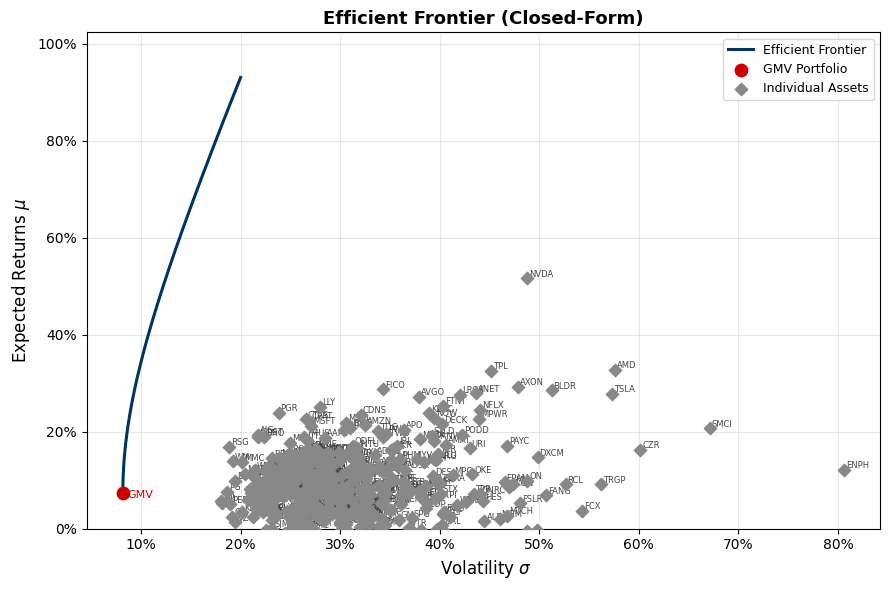

In [46]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sigma_grid, mu_grid, color="#003366", linewidth=2.2, label="Efficient Frontier")
ax.set_ylim(0, mu_grid.max() * 1.1)

ax.scatter(sigma_gmv, mu_gmv, color="#cc0000", zorder=5, s=80, label="GMV Portfolio")
ax.annotate(
    "GMV",
    xy=(sigma_gmv, mu_gmv),
    xytext=(sigma_gmv + 0.005, mu_gmv - 0.01),
    fontsize=8,
    color="#cc0000",
)

ax.scatter(
    asset_sigma,
    asset_mu,
    color="#888888",
    zorder=4,
    s=40,
    marker="D",
    label="Individual Assets",
)
for i, t in enumerate(tickers):
    ax.annotate(
        t,
        xy=(asset_sigma[i], asset_mu[i]),
        xytext=(asset_sigma[i] + 0.002, asset_mu[i] + 0.003),
        fontsize=6,
        color="#444444",
    )

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel(" Volatility $\\sigma$", fontsize=12)
ax.set_ylabel("Expected Returns $\\mu$", fontsize=12)
ax.set_title("Efficient Frontier (Closed-Form)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

#### 3.1 c)

## GMV Portfolio

In [12]:
w_gmv = sigma_inv @ ones / C
mu_gmv = w_gmv @ mu_hat.values
sigma_gmv = np.sqrt(w_gmv @ sigma_hat.values @ w_gmv)

print("GMV Portfolio")
print(f"Expected Return: {mu_gmv:.2%}")
print(f"Std Deviation: {sigma_gmv:.2%}")
print(f"Weights:")
gmv_weights = pd.Series(w_gmv, index=mu_hat.index).sort_values(ascending=False)
print(gmv_weights.to_string())
print(f"Long positions: {(w_gmv > 0).sum()}")
print(f"Short positions: {(w_gmv < 0).sum()}")

GMV Portfolio
Expected Return: 7.35%
Std Deviation: 8.15%
Weights:
ED       0.092081
JNJ      0.087387
VZ       0.084171
HBAN     0.076774
AMCR     0.069394
BK       0.066490
KDP      0.059233
UNP      0.058888
HLT      0.057336
BG       0.057163
WMT      0.056407
CBOE     0.055394
RSG      0.054023
EVRG     0.051683
REG      0.047918
K        0.047808
LMT      0.047083
LIN      0.046324
OMC      0.046303
ICE      0.045972
GOOG     0.044617
AZO      0.044583
ZBH      0.043683
NEM      0.040972
SRE      0.040946
CLX      0.040593
EXPD     0.039110
WTW      0.038371
SNPS     0.038252
MCD      0.038116
PCAR     0.036918
DUK      0.035721
PTC      0.034977
AIZ      0.034316
CPT      0.033960
DIS      0.032776
MRK      0.032670
APH      0.032570
JPM      0.032465
YUM      0.032168
HUM      0.031857
KO       0.031543
GWW      0.030329
PSA      0.030137
V        0.029822
CMG      0.029770
BMY      0.029765
DVA      0.029278
AEP      0.029114
O        0.029074
BDX      0.028295
TMUS     0.0282

### Are the weights reasonable?

Although there's less of a swing between the biggest long and short positions in the GMV portfolio as compared to the Tangency portfolio, the expected returns of this portfolio are very modest, at just 7.35%. Despite being a portfolio that minimizes risk by minimizing the global variance, the standard deviation of this portfolio is larger than the expected returns. 

This indicates that the Sharpe Ratio is below 1: the portfolio is not providing the amount of returns needed for the amount of risk its undertaking. This makes this portfolio allocation unattractive. Additionlly, having around half of the stocks as short positions may induce further risk, because there is infinite downside for undertaking short positions if the stock continues to rise instead of falling. Considering long-only constraints might fix this issue.

## Tangency Portfolio

In [13]:
w_tan_raw = sigma_inv @ mu_hat.values
w_tan = w_tan_raw / (ones @ w_tan_raw)

mu_tan = w_tan @ mu_hat.values
sigma_tan = np.sqrt(w_tan @ sigma_hat.values @ w_tan)
sharpe_tan = mu_tan / sigma_tan

In [14]:
print("\nTangency Portfolio")
print(f"Expected Return: {mu_tan:.2%}")
print(f"Std Deviation: {sigma_tan:.2%}")
print(f"Sharpe Ratio: {sharpe_tan:.4f}")
print(f"Weights:")
tan_weights = pd.Series(w_tan, index=mu_hat.index).sort_values(ascending=False)
print(tan_weights.to_string())
print(f"Long positions: {(w_tan > 0).sum()}")
print(f"Short positions: {(w_tan < 0).sum()}")


Tangency Portfolio
Expected Return: 206.64%
Std Deviation: 43.20%
Sharpe Ratio: 4.7828
Weights:
GOOG     0.506569
DTE      0.403679
ATO      0.388896
LRCX     0.370771
REG      0.355698
JPM      0.348151
WELL     0.346226
ADI      0.337948
MS       0.332089
CAT      0.314306
WRB      0.302973
SO       0.298667
AFL      0.292968
ED       0.276403
FI       0.265532
LLY      0.260898
BRK-B    0.249135
AEP      0.247580
PM       0.239700
STLD     0.239483
PGR      0.236993
PKG      0.233127
DHI      0.229555
TPL      0.217838
AJG      0.217076
MSFT     0.210546
BK       0.208423
IEX      0.202054
PHM      0.198184
AVY      0.197446
JNJ      0.197182
CTAS     0.193269
GRMN     0.187495
KDP      0.187032
DOV      0.186024
PLD      0.185421
ABBV     0.179409
CHD      0.179249
RF       0.177856
FITB     0.173634
TMO      0.171211
MAS      0.168938
BX       0.168602
NWS      0.168382
PNC      0.167720
OKE      0.164328
NVDA     0.162959
WEC      0.162093
DE       0.156083
RCL      0.155821
CBR

### Are the weights reasonable?

The weights for the tangency portfolio show extreme long and short positions. There's approximately a +/-50% swing between the biggest long (**GOOG**) and short (**D**) positions. This translates to extreme levels of risk that the tangency portfolio is bearing, given by an expected return of 206% with a high standard deviation of 43%. 

Additionally, the tangency portfolio looks to hedge on GOOG/GOOGL stocks by longing GOOG and shorting GOOGL. Since the two stocks are share classes of the same parent company (Alphabet), the model seems to overfit the data by exploiting the noise in the dataset, which isn't a realistic strategy to employ.

A more realistic tangency portfolio can be achieved by adding long-only constraints, to avoid the prospect of short-selling.

# Question 3.2

#### 3.2 a)

In [13]:
!pip install cvxpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### Using cvxpy to solve the Std. Dev Minimization Problem (GMV)

In [22]:
import cvxpy as cp

n = len(mu_hat)
w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [cp.sum(w) == 1]
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

###  Verifying if the Solution matches

In [23]:
print(f"Std. Dev: {np.sqrt(solution) * 100:.2f}%")

Std. Dev: 8.15%


The Std. Dev for the GMV portfolio (8.15%) matches the result achieved earlier.

## Adding Long-Only Constraint

In [24]:
n = len(mu_hat)
w = cp.Variable(n)
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [cp.sum(w) == 1, w >= 0]
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

print(f"Std. Dev: {np.sqrt(solution) * 100:.2f}%")

Std. Dev: 12.22%


In [40]:
w_gmv_lo = w.value
mu_gmv_lo = mu_hat.values @ w_gmv_lo
sigma_gmv_lo = np.sqrt(problem.value)

In [41]:
mu_targets = np.linspace(mu_gmv_lo, mu_hat.values.max(), 200)

lo_sigma = []
lo_mu    = []

for mu_target in mu_targets:
    w_lo    = cp.Variable(n)
    obj_lo  = cp.Minimize(cp.quad_form(w_lo, sigma_hat.values))
    con_lo  = [
        cp.sum(w_lo) == 1,
        w_lo >= 0,
        mu_hat.values @ w_lo == mu_target,
    ]
    prob_lo = cp.Problem(obj_lo, con_lo)
    try:
        prob_lo.solve(solver=cp.OSQP, polish=True)
        if prob_lo.status not in ["infeasible", "unbounded"] and w_lo.value is not None:
            lo_sigma.append(np.sqrt(prob_lo.value))
            lo_mu.append(mu_target)
    except Exception:
        pass  # skip any numerically problematic targets

lo_sigma = np.array(lo_sigma)
lo_mu    = np.array(lo_mu)

print(f"Feasible frontier points found: {len(lo_mu)} / {len(mu_targets)}")


/Users/danish/Documents/GitHub/RSM8341-Team11-Assignment1/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/dq/9_kf7lnd13lg7428445qjpmh0000gn/T/ipykernel_59128/3825387847.py:16: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob_lo.solve(solver=cp.OSQP, polish=True)


Feasible frontier points found: 200 / 200


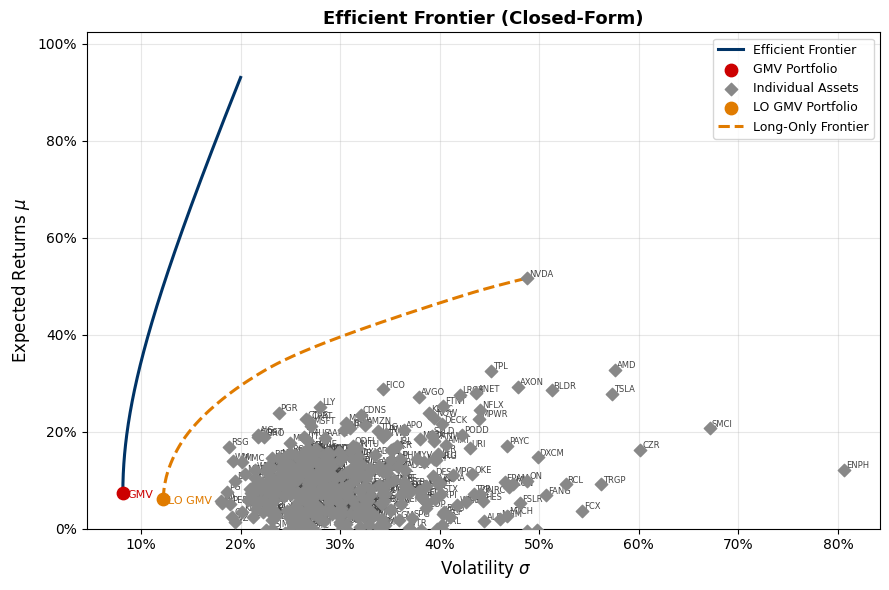

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sigma_grid, mu_grid, color="#003366", linewidth=2.2, label="Efficient Frontier")
ax.set_ylim(0, mu_grid.max() * 1.1)

ax.scatter(sigma_gmv, mu_gmv, color="#cc0000", zorder=5, s=80, label="GMV Portfolio")
ax.annotate(
    "GMV",
    xy=(sigma_gmv, mu_gmv),
    xytext=(sigma_gmv + 0.005, mu_gmv - 0.01),
    fontsize=8,
    color="#cc0000",
)

ax.scatter(
    asset_sigma,
    asset_mu,
    color="#888888",
    zorder=4,
    s=40,
    marker="D",
    label="Individual Assets",
)
for i, t in enumerate(tickers):
    ax.annotate(
        t,
        xy=(asset_sigma[i], asset_mu[i]),
        xytext=(asset_sigma[i] + 0.002, asset_mu[i] + 0.003),
        fontsize=6,
        color="#444444",
    )

# Adding the LO GMV point and frontier
ax.scatter(sigma_gmv_lo, mu_gmv_lo, color="#e07b00", zorder=5, s=80, label="LO GMV Portfolio")
ax.annotate(
    "LO GMV",
    xy=(sigma_gmv_lo, mu_gmv_lo),
    xytext=(sigma_gmv_lo + 0.005, mu_gmv_lo - 0.01),
    fontsize=8, color="#e07b00",
)

ax.plot(lo_sigma, lo_mu, color="#e07b00", linewidth=2.2,
        linestyle="--", label="Long-Only Frontier")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel(" Volatility $\\sigma$", fontsize=12)
ax.set_ylabel("Expected Returns $\\mu$", fontsize=12)
ax.set_title("Efficient Frontier (Closed-Form)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### How do the 2 Frontiers compare?

The unconstrained (short selling allowed) frontier is larger than that of the Long-only frontier curve. Adding extra contraints limits the space of possible risk-return pairs, which shows up in the chart as a smaller curve, as compared to the unconstrained frontier. Adding constraints results in some values from the unconstrained curve not being achievable in the long-only curve. 



In [ ]:
0.024855885254192286

In [57]:
mu_hat.values

array([ 9.19473092e-02,  1.87725365e-01,  1.41989924e-01,  1.02747269e-01,
        1.35193153e-01,  1.26638846e-01,  1.51597835e-01,  1.32596817e-01,
        1.65332655e-03,  1.26923394e-01,  1.21819954e-01,  9.41779205e-02,
        7.38309615e-02, -5.63681848e-03,  1.24118495e-01,  3.65874574e-02,
        1.19194567e-01,  1.93989305e-01, -1.01690316e-02,  1.59329399e-02,
        8.50888705e-02,  1.03046574e-01,  6.14238672e-02,  1.73507274e-01,
        1.77890686e-02,  3.28115744e-01,  1.07435664e-01,  7.21684490e-02,
        1.30025534e-01,  7.33007529e-02,  2.13879829e-01,  2.78956734e-01,
        1.08668398e-01,  1.26334530e-01,  6.45426372e-02, -1.31362228e-01,
        7.60212967e-02,  1.32774655e-01,  2.04481966e-01, -2.65801121e-02,
        1.11545885e-02,  1.04121557e-01,  3.68052766e-02,  2.72348859e-01,
        1.16985430e-01,  9.13239801e-02,  2.92991772e-01,  1.16778124e-01,
        1.43902731e-01, -9.02650957e-03,  9.58700837e-02,  2.12877258e-02,
       -1.56208453e-02,  

In [69]:
n = len(mu_hat)
w = cp.Variable(n)

rf = 0.024855885254192286  # adjust to your risk-free rate
excess_mu = mu_hat.values - rf

objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [excess_mu @ w == 1, w >= 0]  # changed constraint here
problem = cp.Problem(objective, constraints)
solution = problem.solve(solver=cp.OSQP, polish=True)

# Normalize weights to sum to 1
w_tangency_lo = w.value / np.sum(w.value)

# Portfolio statistics
mu_tangency_lo = mu_hat @ w_tangency_lo
sigma_tangency_lo = np.sqrt(w_tangency_lo @ sigma_hat @ w_tangency_lo)
sharpe_tangency_lo = (mu_tangency_lo - rf) / sigma_tangency_lo

print("Long-Only Tangency Portfolio")
print(f"Expected Return: {mu_tangency_lo * 100:.2f}%")
print(f"Std Deviation:   {sigma_tangency_lo * 100:.2f}%")
print(f"Sharpe Ratio:    {sharpe_tangency_lo:.4f}")


Long-Only Tangency Portfolio
Expected Return: 30.25%
Std Deviation:   20.53%
Sharpe Ratio:    1.3527


In [70]:
w_tangency_lo

array([-5.08017173e-22, -3.53187617e-22, -1.96879981e-22, -2.61904723e-22,
       -2.06461861e-22, -3.22383905e-22, -4.01052846e-22, -4.55098390e-22,
       -5.83634660e-22, -2.87969667e-22, -6.18221612e-22, -7.71976312e-23,
       -9.51873483e-23, -6.67027162e-22, -3.73786425e-22, -7.45444166e-22,
       -3.09897317e-22, -6.66056025e-23, -5.49491876e-22, -9.08142638e-22,
       -7.58065505e-22, -4.15085843e-22, -5.07845947e-22, -7.92354469e-22,
       -3.91931520e-22, -2.52932633e-22, -4.22400123e-22, -3.72291516e-22,
       -8.34318029e-22, -2.51342417e-22, -1.61408802e-22, -2.49305051e-22,
       -4.69511560e-22, -2.06430385e-22, -5.30302283e-22, -1.54445655e-21,
       -3.68372602e-22, -3.90984406e-22, -4.05936454e-22, -1.03247213e-21,
       -5.42307080e-22, -7.24463129e-23, -3.76939326e-22, -3.60602151e-22,
       -4.07459853e-22, -9.42793589e-23,  1.77118729e-02, -5.37051984e-22,
       -1.19661716e-22, -9.55226967e-22, -6.32706512e-22, -4.82227753e-22,
       -5.53827996e-22, -

In [ ]:
n = len(mu_hat)
w = cp.Variable(n)

rf = 0.024855885254192286  # Adjust to your risk-free rate
excess_mu = mu_hat.values - rf

# Define the optimization problem
objective = cp.Minimize(cp.quad_form(w, sigma_hat))
constraints = [excess_mu @ w == 1, w >= 0]
problem = cp.Problem(objective, constraints)

# Solve the problem using a more robust solver
solution = problem.solve(solver=cp.SCS)  # Try SCS or ECOS

# Normalize weights to sum to 1 and clip small negatives
w_tangency_lo = np.maximum(w.value, 0)  # Clip negative weights to 0
w_tangency_lo /= np.sum(w_tangency_lo)  # Renormalize to sum to 1

# Portfolio statistics
mu_tangency_lo = mu_hat @ w_tangency_lo
sigma_tangency_lo = np.sqrt(w_tangency_lo @ sigma_hat @ w_tangency_lo)
sharpe_tangency_lo = (mu_tangency_lo - rf) / sigma_tangency_lo

# Print results
print("Long-Only Tangency Portfolio")
print(f"Expected Return: {mu_tangency_lo * 100:.2f}%")
print(f"Std Deviation:   {sigma_tangency_lo * 100:.2f}%")
print(f"Sharpe Ratio:    {sharpe_tangency_lo:.4f}")

# Verify constraints
print("Are all weights non-negative?", np.all(w_tangency_lo >= 0))
print("Do weights sum to 1?", np.isclose(np.sum(w_tangency_lo), 1))

# Print weights
import pandas as pd
weights_series = pd.Series(w_tangency_lo, index=tickers)
print("\nTangency Portfolio Weights:")
print(weights_series[weights_series > 0.001].sort_values(ascending=False))


Long-Only Tangency Portfolio
Expected Return: 30.25%
Std Deviation:   20.53%
Sharpe Ratio:    1.3526
Are all weights non-negative? True
Do weights sum to 1? True

Tangency Portfolio Weights:
PGR     0.314063
LLY     0.221358
NVDA    0.204901
TPL     0.111221
COST    0.070397
          ...   
IFF     0.000000
INCY    0.000000
INTC    0.000000
IP      0.000000
ZTS     0.000000
Length: 472, dtype: float64
